# MPC minutes preprocessing
Load, clean, and tokenize the MPC minutes according to the assignment instructions.

For the first part of the assignment:

(20 points) Load the MPC data, and pre-process the data.
- lower-case text
- expand contractions
- split the documents into tokens
- remove non-ascii characters, remove short tokens, remove punctuation and
numbers, remove stopwords
- stemming and lemmatization

In [7]:
# Imports and NLTK resources
from pathlib import Path
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Ensure required tokenizers and corpora are available
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [8]:
# Load raw MPC minutes
data_path = Path("../raw/mpc_minutes.txt")
raw_text = data_path.read_text(encoding="utf-8", errors="ignore")
documents = [line.strip() for line in raw_text.splitlines() if line.strip()]
print(f"Loaded {len(documents)} documents from {data_path}")

Loaded 7278 documents from ../raw/mpc_minutes.txt


In [9]:
# Contraction expansion helper
try:
    import contractions
    def expand_contractions(text: str) -> str:
        return contractions.fix(text)
except ImportError:
    CONTRACTION_MAP = {
        "n't": " not",
        "'re": " are",
        "'s": " is",
        "'d": " would",
        "'ll": " will",
        "'ve": " have",
        "'m": " am"
    }
    contraction_pattern = re.compile("|".join(map(re.escape, CONTRACTION_MAP.keys())))
    def expand_contractions(text: str) -> str:
        return contraction_pattern.sub(lambda m: CONTRACTION_MAP[m.group(0)], text)

In [10]:
# Tokenization and normalization pipeline
def preprocess_document(text: str) -> dict:
    text = text.lower()
    text = expand_contractions(text)
    tokens = word_tokenize(text)
    cleaned = []
    for tok in tokens:
        tok_ascii = tok.encode("ascii", "ignore").decode("ascii")
        if not tok_ascii:
            continue
        if len(tok_ascii) < 3:
            continue
        if not tok_ascii.isalpha():
            continue
        if tok_ascii in stop_words:
            continue
        cleaned.append(tok_ascii)
    stemmed = [stemmer.stem(t) for t in cleaned]
    lemmatized = [lemmatizer.lemmatize(t) for t in cleaned]
    return {
        "tokens": cleaned,
        "stemmed": stemmed,
        "lemmatized": lemmatized
    }

In [11]:
# Apply preprocessing and inspect a sample
processed_docs = [preprocess_document(doc) for doc in documents]
print(f"Preprocessed {len(processed_docs)} documents")

if processed_docs:
    sample = processed_docs[0]
    print("Tokens (first doc, first 30):", sample["tokens"][:30])
    print("Stemmed (first 30):", sample["stemmed"][:30])
    print("Lemmas (first 30):", sample["lemmatized"][:30])

Preprocessed 7278 documents
Tokens (first doc, first 30): ['year', 'minutes']
Stemmed (first 30): ['year', 'minut']
Lemmas (first 30): ['year', 'minute']


For the second part of the assignment:

(15 points) Count and the frequency.
- generate document frequency (df) ranking for stems
- show the top 10 stems
- plot the df ranking

Top 10 stems by document frequency:
growth: 3431
rate: 3342
inflat: 3062
committe: 2982
price: 2830
month: 2783
market: 2754
would: 2704
increas: 2529
expect: 2464


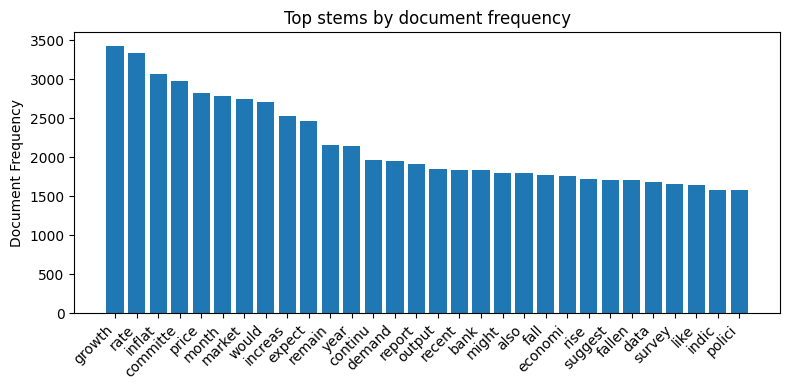

In [12]:
# Document frequency for stems
from collections import Counter
import matplotlib.pyplot as plt

if not processed_docs:
    raise ValueError("Run preprocessing first to populate processed_docs.")

unique_stems_per_doc = [set(doc["stemmed"]) for doc in processed_docs]
df_counter = Counter()
for stems in unique_stems_per_doc:
    df_counter.update(stems)

top10 = df_counter.most_common(10)
print("Top 10 stems by document frequency:")
for stem, df in top10:
    print(f"{stem}: {df}")

stems, dfs = zip(*df_counter.most_common(30)) if df_counter else ([], [])
plt.figure(figsize=(8, 4))
plt.bar(range(len(stems)), dfs)
plt.xticks(range(len(stems)), stems, rotation=45, ha="right")
plt.ylabel("Document Frequency")
plt.title("Top stems by document frequency")
plt.tight_layout()
plt.show()

For the third part of the assignment:

Term frequency inverse document frequency (TF-IDF).
- generate TF-IDF ranking of stems
- show the top 10 stems
- plot TF-IDF ranking
- remove stems with a TF-IDF score <= 3,500
- apply the removal and create a new document-term matrix, show the matrix
(num_documents x num_terms)

Top 10 stems by TF-IDF (sum over documents):
inflat: 401.46
growth: 387.33
rate: 368.01
price: 355.99
market: 272.11
committe: 256.82
month: 248.62
would: 247.19
expect: 229.37
increas: 229.21


/opt/anaconda3/envs/5020_env/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


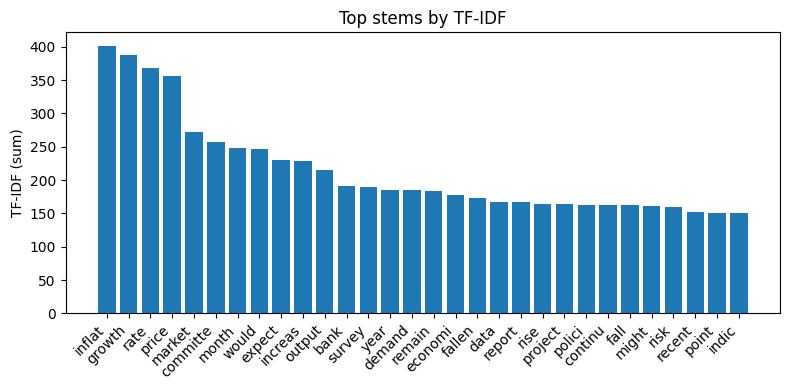

Filtered matrix shape: (7278, 0) (docs x terms) with threshold > 3500
No terms exceed the TF-IDF threshold; consider lowering it.


In [13]:
# TF-IDF on stems
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not processed_docs:
    raise ValueError("Run preprocessing first to populate processed_docs.")

corpus = [" ".join(doc["stemmed"]) for doc in processed_docs]
vectorizer = TfidfVectorizer(tokenizer=lambda x: x.split(), preprocessor=lambda x: x, lowercase=False)
tfidf_matrix = vectorizer.fit_transform(corpus)
terms = vectorizer.get_feature_names_out()
tfidf_sum = tfidf_matrix.sum(axis=0).A1

ranking = sorted(zip(terms, tfidf_sum), key=lambda x: x[1], reverse=True)
top10 = ranking[:10]
print("Top 10 stems by TF-IDF (sum over documents):")
for term, score in top10:
    print(f"{term}: {score:.2f}")

top_terms, top_scores = zip(*ranking[:30]) if ranking else ([], [])
plt.figure(figsize=(8, 4))
plt.bar(range(len(top_terms)), top_scores)
plt.xticks(range(len(top_terms)), top_terms, rotation=45, ha="right")
plt.ylabel("TF-IDF (sum)")
plt.title("Top stems by TF-IDF")
plt.tight_layout()
plt.show()

threshold = 3500
mask = tfidf_sum > threshold
filtered_terms = terms[mask]
filtered_matrix = tfidf_matrix[:, mask]
print(f"Filtered matrix shape: {filtered_matrix.shape} (docs x terms) with threshold > {threshold}")

if filtered_matrix.shape[1] == 0:
    print("No terms exceed the TF-IDF threshold; consider lowering it.")
else:
    dtm = pd.DataFrame(filtered_matrix.toarray(), columns=filtered_terms)
    print("Document-term matrix (first 5 rows):")
    display(dtm.head())

For the fourth part of the assignment:

(40 points) LDA topic model.
- create a LDA object with 30 topics (set the hyperparameter of the Dirichlet prior on topics to 200/number of unique vocabulary elements, set the hyperparameter of the Dirichlet prior on document-topic distributions to 50/number of topics, set the number of sampling iterations be 5000, set the random_state to make sure re-productivity)
- estimate the model (may take 5-10 minutes)
- show the distribution of topics over documents and probability distribution over the vocabulary
- show the top 15 words with highest probability per topic
- create a figure for the first 15 topics
- choose three topics and interpret them (try to summarize the likely topics)

LDA topic model (30 topics).

In [ ]:
# Fit LDA with Dirichlet priors
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

if not processed_docs:
    raise ValueError("Run preprocessing first to populate processed_docs.")

corpus = [" ".join(doc["stemmed"]) for doc in processed_docs]
vectorizer_lda = CountVectorizer(tokenizer=lambda x: x.split(), preprocessor=lambda x: x, lowercase=False)
dtm_counts = vectorizer_lda.fit_transform(corpus)
vocab = vectorizer_lda.get_feature_names_out()
if dtm_counts.shape[1] == 0:
    raise ValueError("Vocabulary is empty after preprocessing; check earlier steps.")

n_topics = 30
alpha_raw = 50 / n_topics
doc_prior = min(alpha_raw, 1.0)  # sklearn requires doc_topic_prior in [0,1]
eta = 200 / len(vocab) if len(vocab) > 0 else 1.0

lda = LatentDirichletAllocation(
    n_components=n_topics,
    doc_topic_prior=doc_prior,
    topic_word_prior=eta,
    max_iter=5000,
    learning_method="batch",
    random_state=0,
    evaluate_every=-1,
    verbose=0
)
lda.fit(dtm_counts)

doc_topic = lda.transform(dtm_counts)
topic_word = lda.components_ / lda.components_.sum(axis=1, keepdims=True)
print(f"Doc-topic matrix shape: {doc_topic.shape} (docs x topics)")
print(f"Topic-word matrix shape: {topic_word.shape} (topics x vocab)")

In [ ]:
# Inspect top words per topic and topic weights per doc
import pandas as pd
import numpy as np

def top_words_per_topic(topic_word_matrix, vocab_list, topn=15):
    result = []
    for k, weights in enumerate(topic_word_matrix):
        top_idx = np.argsort(weights)[::-1][:topn]
        result.append((k, [(vocab_list[i], weights[i]) for i in top_idx]))
    return result

top_words = top_words_per_topic(topic_word, vocab, topn=15)
for k, words in top_words:
    words_str = ", ".join([f"{w} ({p:.4f})" for w, p in words])
    print(f"Topic {k}: {words_str}")

doc_topic_df = pd.DataFrame(doc_topic, columns=[f"topic_{i}" for i in range(doc_topic.shape[1])])
print("Doc-topic distribution (first 5 docs):")
display(doc_topic_df.head())

NameError: name 'topic_word' is not defined

In [ ]:
# Plot top 15 topics with top 15 words each
import matplotlib.pyplot as plt

num_to_plot = min(15, len(top_words))
fig, axes = plt.subplots(3, 5, figsize=(15, 9), constrained_layout=True)
for idx in range(num_to_plot):
    ax = axes.flat[idx]
    words, probs = zip(*top_words[idx][1])
    ax.bar(range(len(words)), probs)
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"Topic {idx}")
    ax.set_ylabel("P(word|topic)")
for ax in axes.flat[num_to_plot:]:
    ax.axis("off")
plt.show()

NameError: name 'top_words' is not defined

Interpretation notes (fill after inspecting outputs):
- Topic __: likely about ...
- Topic __: likely about ...
- Topic __: likely about ...